# Task 1: Fraud Detection EDA & Preprocessing

This notebook covers the data analysis and preprocessing steps for the Fraud Detection project.
We will:
1. Load the `Fraud_Data.csv` and `IpAddress_to_Country.csv` datasets.
2. Perform geolocation mapping (IP to Country).
3. Engineer time-based and frequency-based features.
4. Analyze data distributions, missing values, and class imbalance.
5. Save the processed dataset for modeling.
6. Briefly inspect `creditcard.csv`.

In [11]:
import sys
sys.path.append('../')

import importlib
import pandas as pd
import numpy as np
from pathlib import Path

from src.visualisation import plotter as plotter_module
from src.preprocessing import eda_utils as eda_utils_module
from src.features import fraud_features as fraud_features_module

pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:.4f}".format

ROOT = Path("..").resolve()
RAW_DIR = ROOT / "data" / "raw"
RAW_PATH = RAW_DIR / "Fraud_Data.csv"
PROCESSED_PATH = ROOT / "data" / "processed" / "Fraud_Data_Processed.csv"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plotter_module = importlib.reload(plotter_module)
eda_utils_module = importlib.reload(eda_utils_module)
fraud_features_module = importlib.reload(fraud_features_module)

Plotter = plotter_module.Plotter
from src.preprocessing.eda_utils import (
    missingness_summary,
    top_frequencies,
    flag_outliers_iqr,
    constant_columns,
    cardinality_report,
    class_balance,
    compute_target_correlations,
    correlation_matrix,
    add_log1p_column,
    duplicates_count,
    dtypes_frame,
    sample_df,
    describe_by_class,
)
from src.features.fraud_features import (
    merge_ip_country, 
    add_time_features, 
    add_transaction_frequency
)

plotter = Plotter(figures_dir=FIG_DIR)

print(f"Raw path: {RAW_PATH}")
print(f"Processed path (will write): {PROCESSED_PATH}")

Raw path: C:\BackUp\web-projects\tenx\bank-fraud-week5-6\data\raw\Fraud_Data.csv
Processed path (will write): C:\BackUp\web-projects\tenx\bank-fraud-week5-6\data\processed\Fraud_Data_Processed.csv


### 1. Load Data
Load the `Fraud_Data.csv` and `IpAddress_to_Country.csv` datasets.

In [2]:
# Load Datasets
fraud_df = pd.read_csv(RAW_PATH)
ip_country_df = pd.read_csv(RAW_DIR / "IpAddress_to_Country.csv")

print(f"Fraud Data Shape: {fraud_df.shape}")
print(f"IP Country Data Shape: {ip_country_df.shape}")

fraud_df.head()

Fraud Data Shape: (151112, 11)
IP Country Data Shape: (138846, 3)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,732758368.7997,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,350311387.8659,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2621473820.1109,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3840542443.9140,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,415583117.4527,0


### 2. Feature Engineering
- Map IP addresses to countries.
- Create time-based features (`time_since_signup`, `hour_of_day`, `day_of_week`).
- Create transaction frequency features.

In [3]:
# Merge IP to Country
fraud_df = merge_ip_country(fraud_df, ip_country_df)

# Add Time Features
fraud_df = add_time_features(fraud_df)

# Add Transaction Frequency Features
fraud_df = add_transaction_frequency(fraud_df)

print("Feature Engineering Complete.")
fraud_df.head()

Feature Engineering Complete.


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country,time_since_signup,hour_of_day,day_of_week,purchase_month,user_txn_count,device_txn_count,ip_txn_count
0,62421,2015-02-16 00:17:05,2015-03-08 10:00:39,46,ZCLZTAJPCRAQX,Direct,Safari,M,36,52093.4969,0,NaN,1763014.0000,10,6,3,1,1,1
1,173212,2015-03-08 04:03:22,2015-03-20 17:23:45,33,YFGYOALADBHLT,Ads,IE,F,30,93447.1390,0,NaN,1084823.0000,17,4,3,1,1,1
2,242286,2015-05-17 16:45:54,2015-05-26 08:54:34,33,QZNVQTUITFTHH,Direct,FireFox,F,32,105818.5015,0,NaN,749320.0000,8,1,5,1,1,1
3,370003,2015-03-03 19:58:39,2015-05-28 21:09:13,33,PIBUQMBIELMMG,Ads,IE,M,40,117566.6649,0,NaN,7434634.0000,21,3,5,1,1,1
4,119824,2015-03-20 00:31:27,2015-04-05 07:31:46,55,WFIIFCPIOGMHT,Ads,Safari,M,38,131423.7890,0,NaN,1407619.0000,7,6,4,1,1,1


### 3. Exploratory Data Analysis (EDA)
Analyze missing values, class imbalance, and distributions.

In [4]:
# Missing Values
missing_summary = missingness_summary(fraud_df)
display(missing_summary)

,missing_pct,dtype,non_null
country,14.5400,object,129140.3152
signup_time,0.0000,datetime64[ns],151112.0000
user_id,0.0000,int64,151112.0000
purchase_time,0.0000,datetime64[ns],151112.0000
purchase_value,0.0000,int64,151112.0000
source,0.0000,object,151112.0000
device_id,0.0000,object,151112.0000
sex,0.0000,object,151112.0000
age,0.0000,int64,151112.0000
ip_address,0.0000,float64,151112.0000


,class,count,share
0,0,136961,0.9064
1,1,14151,0.0936


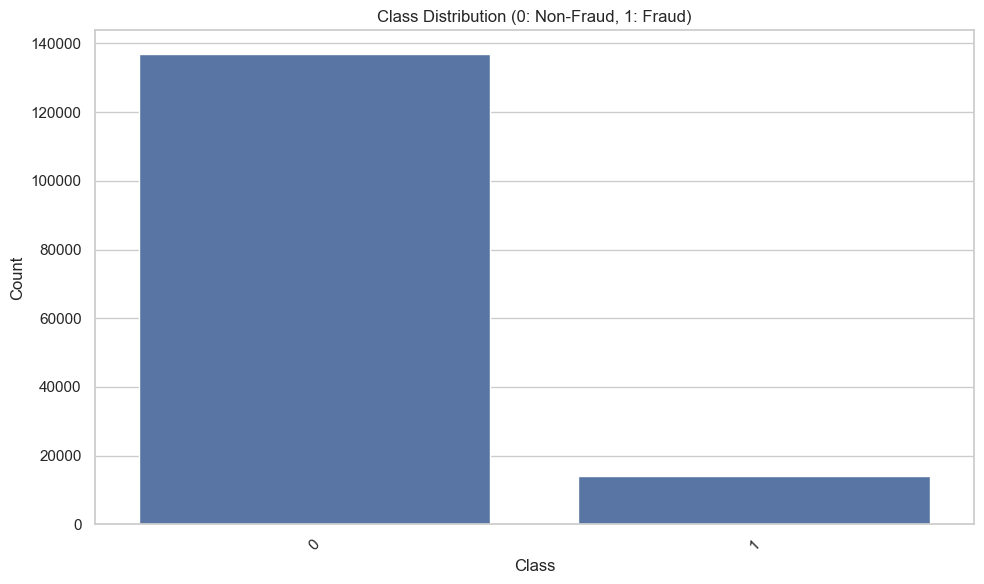

In [5]:
# Class Imbalance
balance = class_balance(fraud_df, ["class"])
display(balance)

plotter.plot_bar(
    balance.reset_index(), 
    x='index', 
    y='count', 
    title="Class Distribution (0: Non-Fraud, 1: Fraud)",
    xlabel="Class",
    ylabel="Count"
)

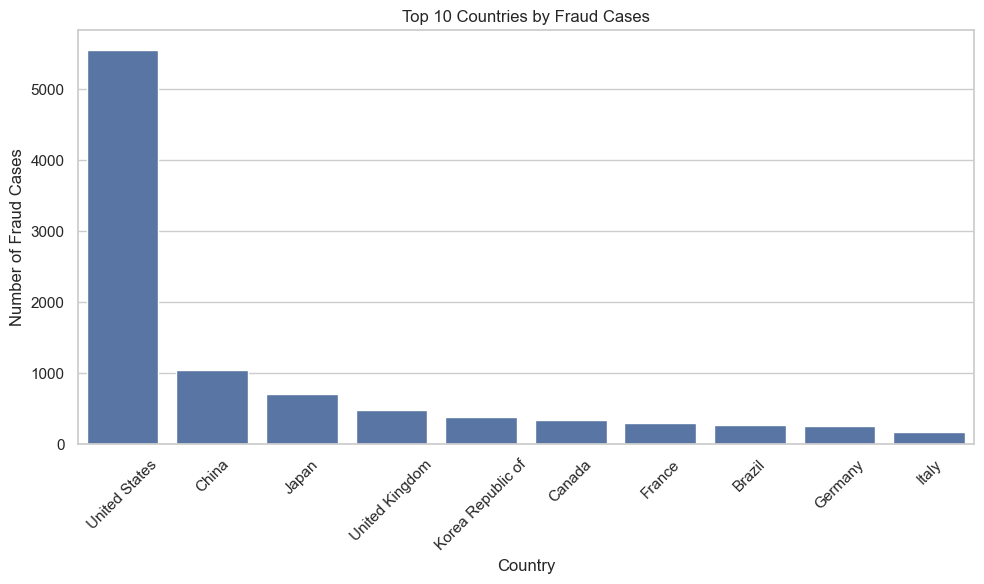

In [6]:
# Fraud by Country
country_fraud = fraud_df[fraud_df['class'] == 1]['country'].value_counts().head(10).reset_index()
country_fraud.columns = ['country', 'count']

plotter.plot_bar(
    country_fraud, 
    x='country', 
    y='count', 
    title="Top 10 Countries by Fraud Cases",
    xlabel="Country",
    ylabel="Number of Fraud Cases"
)

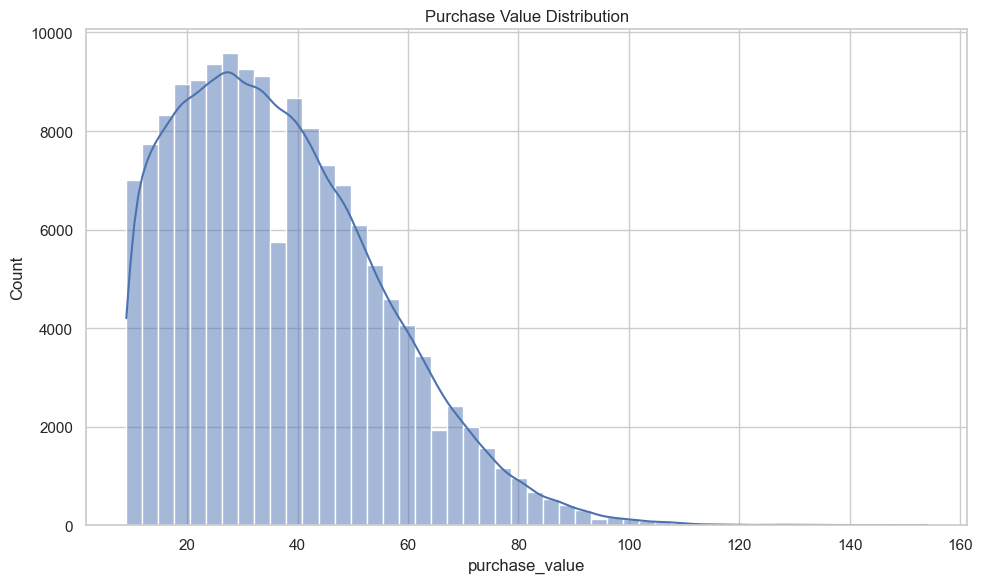

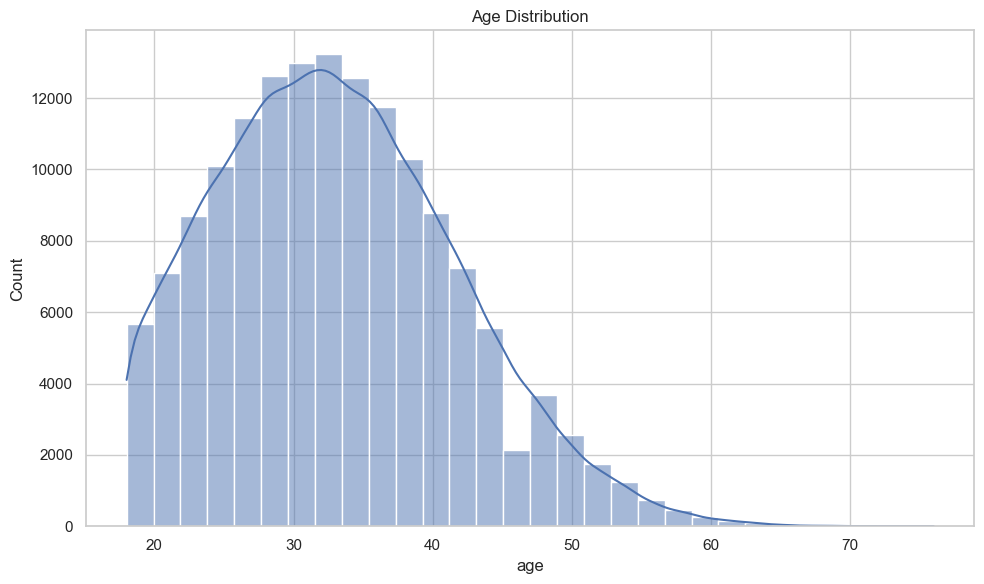

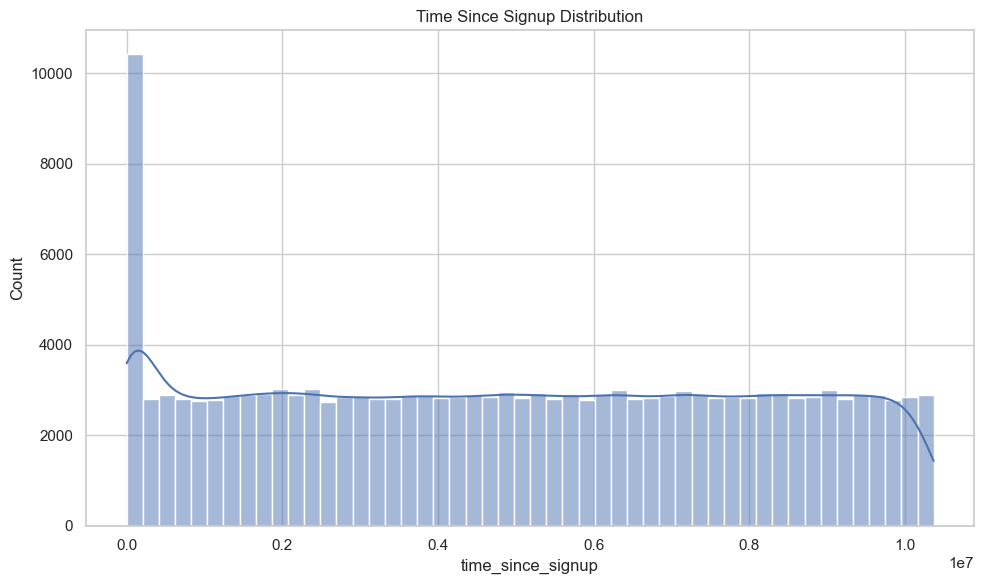

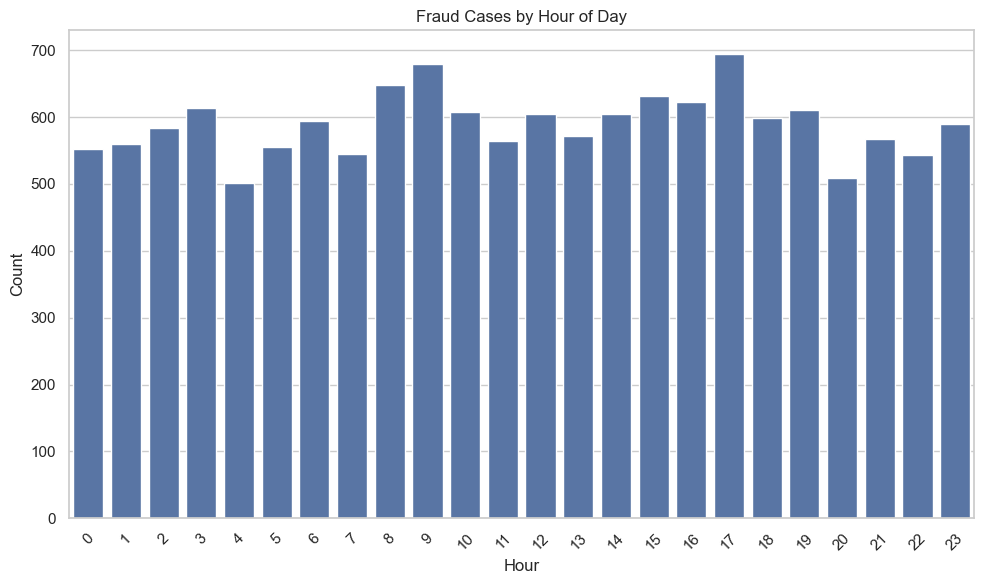

In [7]:
# Distributions
plotter.plot_histogram(fraud_df, 'purchase_value', title="Purchase Value Distribution", bins=50)
plotter.plot_histogram(fraud_df, 'age', title="Age Distribution", bins=30)
plotter.plot_histogram(fraud_df, 'time_since_signup', title="Time Since Signup Distribution", bins=50)

# Fraud by Hour
fraud_by_hour = fraud_df[fraud_df['class'] == 1]['hour_of_day'].value_counts().sort_index().reset_index()
fraud_by_hour.columns = ['hour_of_day', 'count']
plotter.plot_bar(fraud_by_hour, x='hour_of_day', y='count', title="Fraud Cases by Hour of Day", xlabel="Hour", ylabel="Count")

### 4. Save Processed Data

In [8]:
# Save the enriched dataset
fraud_df.to_csv(PROCESSED_PATH, index=False)
print(f"Saved processed data to {PROCESSED_PATH}")

Saved processed data to C:\BackUp\web-projects\tenx\bank-fraud-week5-6\data\processed\Fraud_Data_Processed.csv


### 5. Credit Card Dataset Overview (Optional)

In [9]:
try:
    credit_df = pd.read_csv(RAW_DIR / "creditcard.csv")
    print(f"Credit Card Data Shape: {credit_df.shape}")
    display(credit_df.head())
    display(credit_df['Class'].value_counts(normalize=True))
except Exception as e:
    print(f"Could not load creditcard.csv: {e}")

Credit Card Data Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


Class
0   0.9983
1   0.0017
Name: proportion, dtype: float64

### 5a. Additional Credit Card EDA
Use only helper utilities for summaries, distributions, correlations, and plots.

,column,dtype
0,Time,float64
1,V1,float64
2,V2,float64
3,V3,float64
4,V4,float64
5,V5,float64
6,V6,float64
7,V7,float64
8,V8,float64
9,V9,float64


,missing_pct,dtype,non_null
Time,0.0000,float64,284807.0000
V1,0.0000,float64,284807.0000
V2,0.0000,float64,284807.0000
V3,0.0000,float64,284807.0000
V4,0.0000,float64,284807.0000
V5,0.0000,float64,284807.0000
V6,0.0000,float64,284807.0000
V7,0.0000,float64,284807.0000
V8,0.0000,float64,284807.0000
V9,0.0000,float64,284807.0000


Duplicate full rows: 1081


,Class,count,share
0,0,284315,0.9983
1,1,492,0.0017


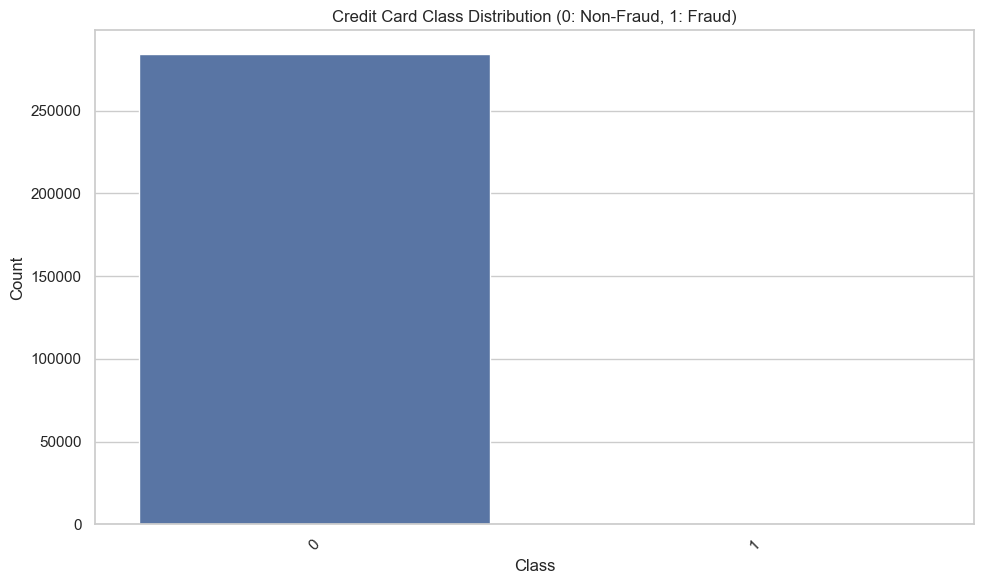

In [12]:
# Ensure credit_df is available from the previous load cell
if 'credit_df' in globals():
    # Dtypes and missingness via helpers
    display(dtypes_frame(credit_df, max_rows=40))
    display(missingness_summary(credit_df))

    # Duplicates and class balance via helpers
    dup_count = duplicates_count(credit_df)
    print(f"Duplicate full rows: {dup_count}")

    cc_balance = class_balance(credit_df, ["Class"])
    display(cc_balance)

    plotter.plot_bar(
        cc_balance.reset_index(),
        x="index",
        y="count",
        title="Credit Card Class Distribution (0: Non-Fraud, 1: Fraud)",
        xlabel="Class",
        ylabel="Count",
    )
else:
    print("credit_df is not loaded; run the previous cell to load it.")

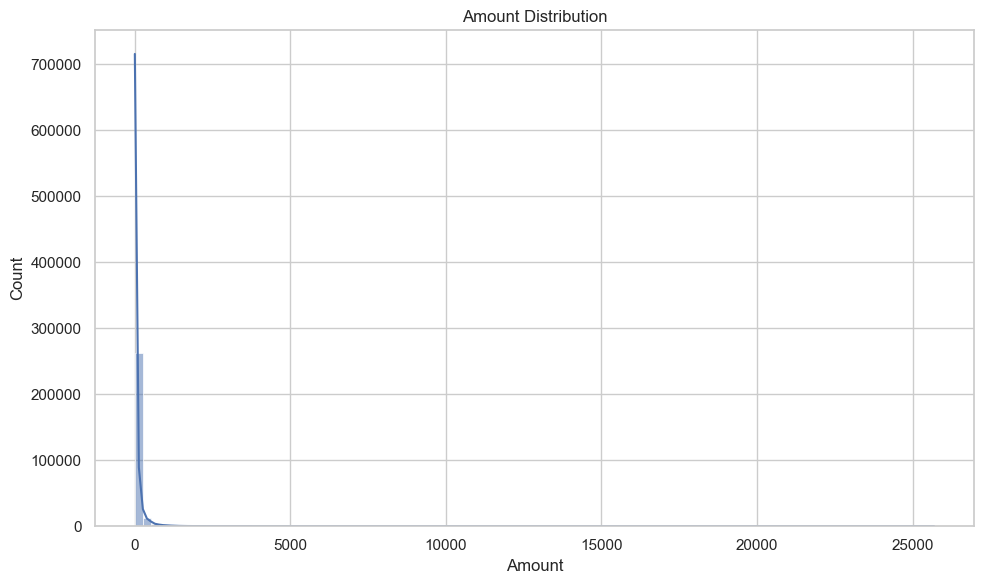

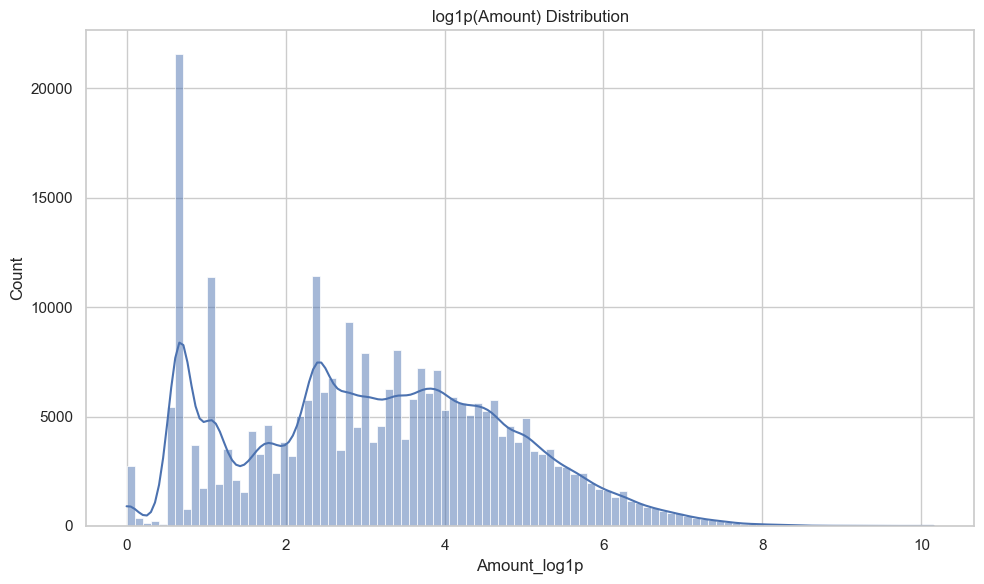

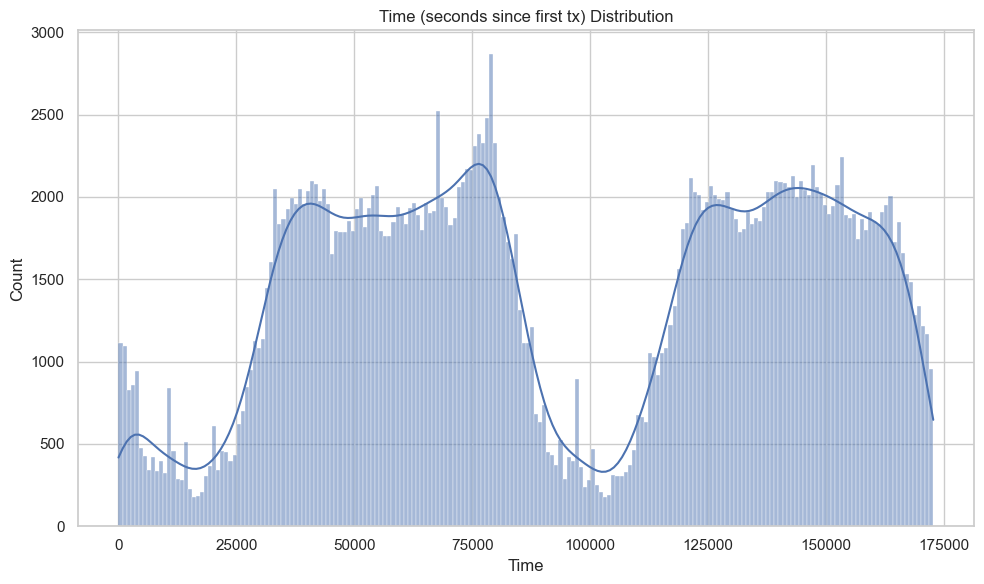

Amount                                                      \
            count     mean      std    min     50%      90%       99%   
Class                                                                   
0     284315.0000  88.2910 250.1051 0.0000 22.0000 202.7240 1016.9664   
1        492.0000 122.2113 256.6833 0.0000  9.2500 346.7460 1357.4279   

                  
             max  
Class             
0     25691.1600  
1      2125.8700

In [13]:
# Distributions using helpers only
if 'credit_df' in globals():
    # Amount distributions and log1p transform via helper
    plotter.plot_histogram(credit_df, 'Amount', title="Amount Distribution", bins=100)

    credit_df_log = add_log1p_column(credit_df, 'Amount', new_name='Amount_log1p')
    plotter.plot_histogram(credit_df_log, 'Amount_log1p', title="log1p(Amount) Distribution", bins=100)

    # Time distribution
    plotter.plot_histogram(credit_df, 'Time', title="Time (seconds since first tx) Distribution", bins=200)

    # Amount by Class descriptive stats via helper
    display(describe_by_class(credit_df, 'Class', ['Amount'], percentiles=(0.5, 0.9, 0.99)))
else:
    print("credit_df is not loaded; run the previous cell to load it.")

,feature,corr,abs_corr
0,V17,-0.3265,0.3265
1,V14,-0.3025,0.3025
2,V12,-0.2606,0.2606
3,V10,-0.2169,0.2169
4,V16,-0.1965,0.1965
5,V3,-0.1930,0.1930
6,V7,-0.1873,0.1873
7,V11,0.1549,0.1549
8,V4,0.1334,0.1334
9,V18,-0.1115,0.1115


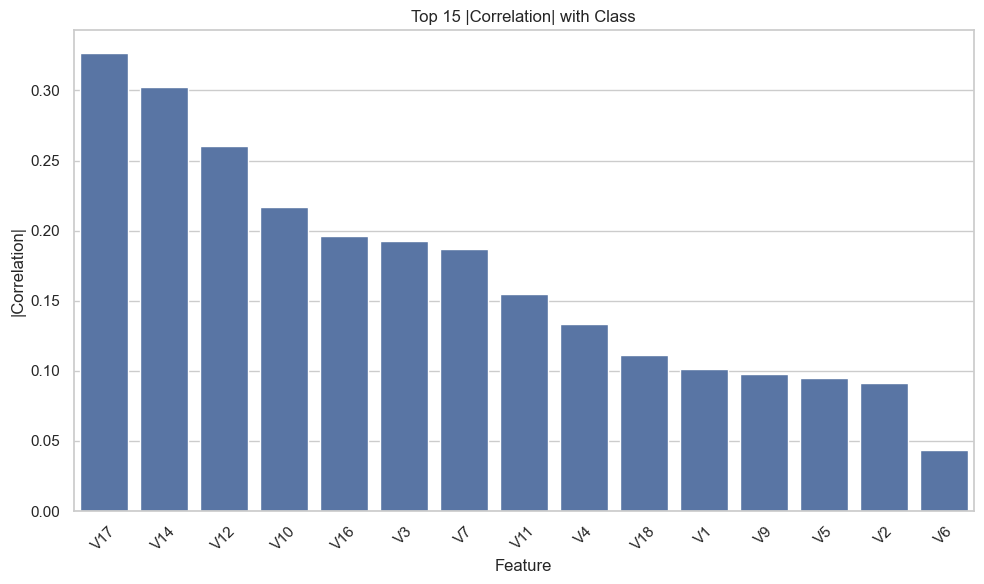

In [14]:
# Feature correlations with Class using helpers only
if 'credit_df' in globals():
    corr_df = compute_target_correlations(credit_df, target='Class')
    display(corr_df.head(20))

    top_n = 15
    plotter.plot_bar(
        corr_df.head(top_n),
        x="feature",
        y="abs_corr",
        title=f"Top {top_n} |Correlation| with Class",
        xlabel="Feature",
        ylabel="|Correlation|",
    )
else:
    print("credit_df is not loaded; run the previous cell to load it.")

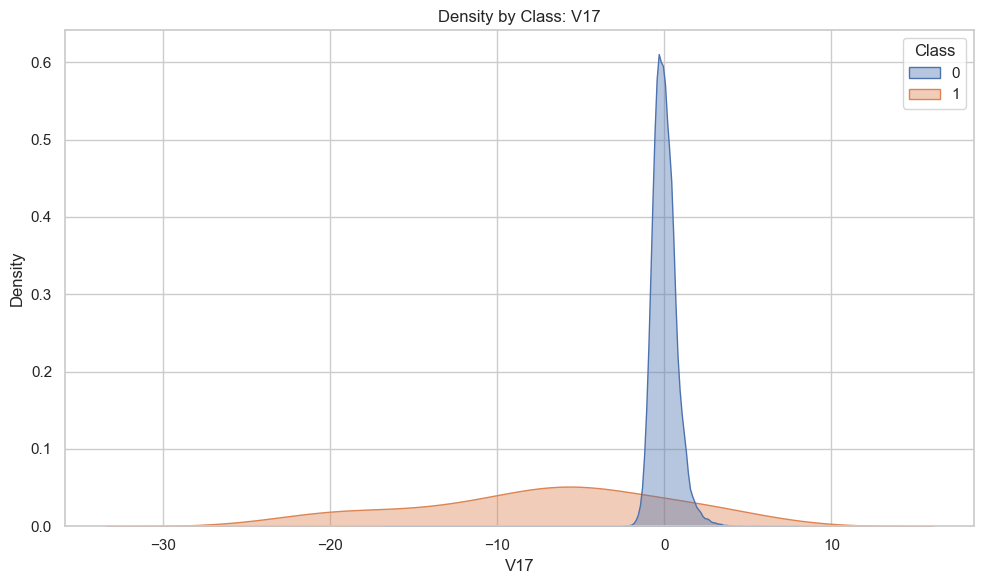

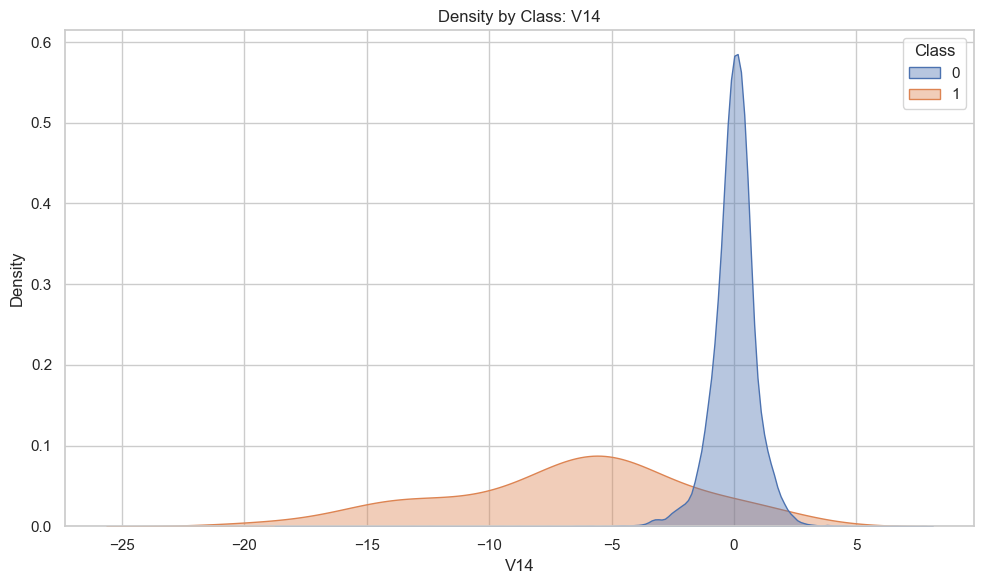

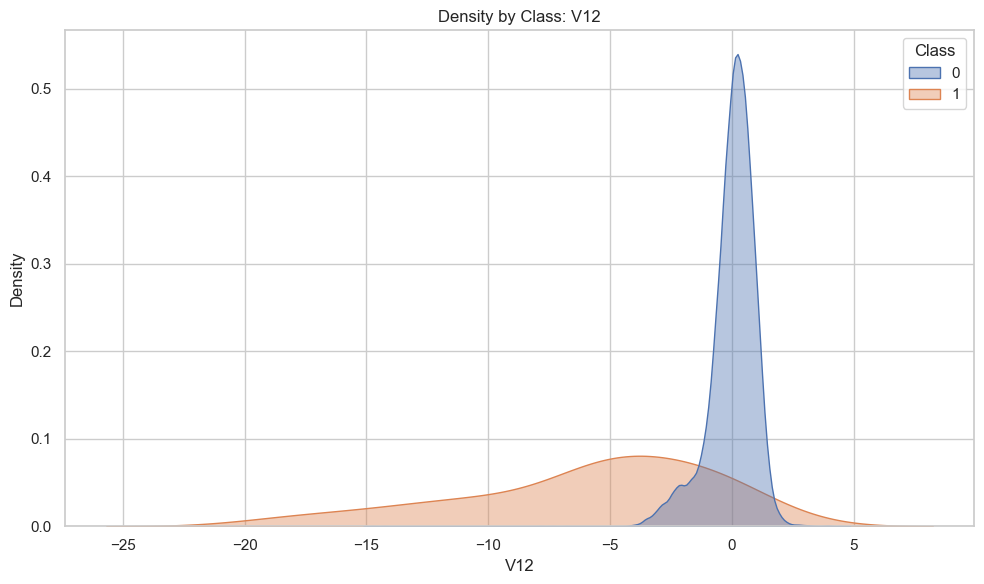

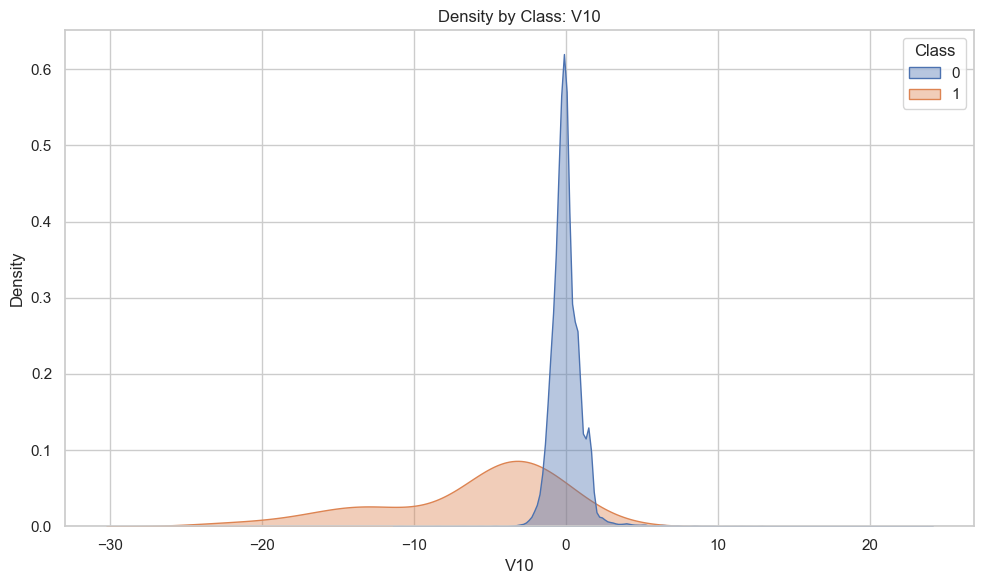

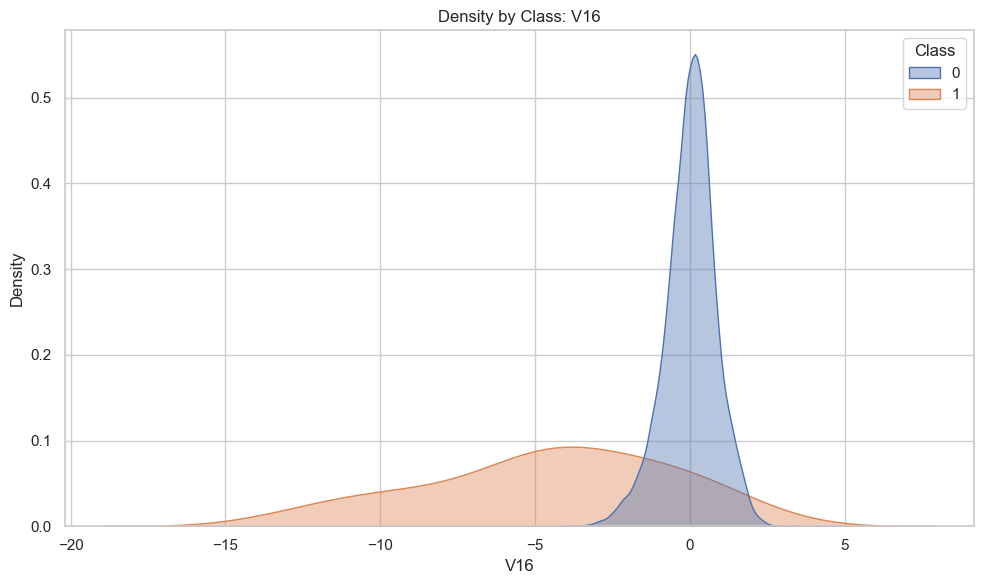

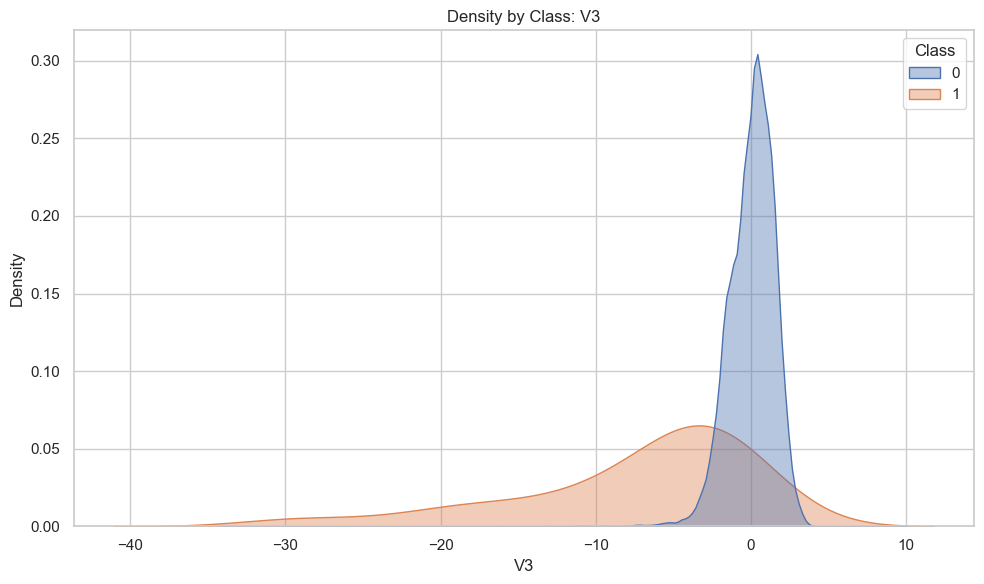

In [15]:
# Per-class density plots for top features using helpers only
if 'credit_df' in globals():
    corr_df = compute_target_correlations(credit_df, target='Class')
    top_feats = corr_df.head(6)['feature'].tolist()
    sample = sample_df(credit_df, n=25000, random_state=42)

    for f in top_feats:
        plotter.plot_density_by_class(
            sample,
            x=f,
            class_col='Class',
            title=f"Density by Class: {f}",
            xlabel=f,
            ylabel="Density",
            bw_adjust=1.0,
            fill=True,
            alpha=0.4,
        )
else:
    print("credit_df is not loaded; run the previous cell to load it.")

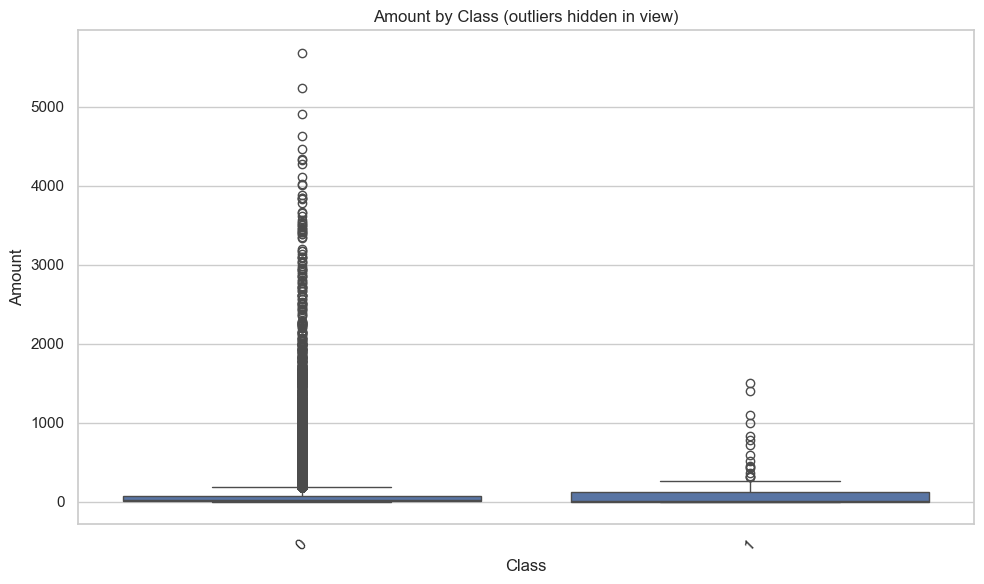

In [16]:
# Amount by Class (boxplot) using helpers only
if 'credit_df' in globals():
    sample = sample_df(credit_df, n=50000, random_state=42)
    plotter.plot_box(
        sample,
        y="Amount",
        x="Class",
        title="Amount by Class (outliers hidden in view)",
        xlabel="Class",
        ylabel="Amount",
    )
else:
    print("credit_df is not loaded; run the previous cell to load it.")

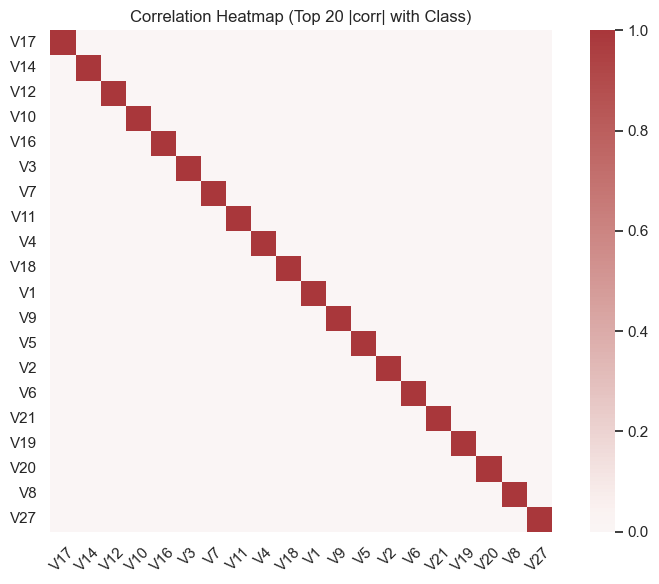

In [17]:
# Correlation heatmap (top 20 |corr| features) using helpers only
if 'credit_df' in globals():
    corr_df = compute_target_correlations(credit_df, target='Class')
    top20 = corr_df.head(20)['feature'].tolist()
    corr_mat = correlation_matrix(credit_df, top20)
    plotter.plot_heatmap(
        corr_mat,
        title="Correlation Heatmap (Top 20 |corr| with Class)",
        cmap="vlag",
        center=0,
        square=True,
        annot=False,
        figsize=(8,6),
    )
else:
    print("credit_df is not loaded; run the previous cell to load it.")

figures
- Class Distribution (0: Non-Fraud, 1: Fraud)
- Top 10 Countries by Fraud Cases
- Purchase Value Distribution
- Age Distribution
- Time Since Signup Distribution
- Fraud Cases by Hour of Day
- Credit Card Class Distribution (0: Non-Fraud, 1: Fraud)
- Amount Distribution
- log1p(Amount) Distribution
- Time (seconds since first tx) Distribution
- Top |Correlation| with Class (Credit Card)
- Density by Class (V17, V14, V12, V10, V16, V3)
- Amount by Class (outliers hidden in view)
- Correlation Heatmap (Top 20 |corr| with Class)